<a href="https://colab.research.google.com/github/Mounikapaili/Mounika/blob/main/FlightPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [3]:
df=pd.read_csv("/content/TA Aadhya1.csv")
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [10]:
df['hours']=df['duration'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
 12  hours             300153 non-null  int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 29.8+ MB


In [17]:
df["minutes"]=((df['duration']-df['hours'])*60).astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
 12  hours             300153 non-null  int64  
 13  minutes           300153 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 32.1+ MB


In [18]:
df.drop(columns=['duration'])

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price,hours,minutes
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,1,5953,2,10
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,1,5953,2,19
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,1,5956,2,10
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,1,5955,2,15
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,1,5955,2,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,49,69265,10,4
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,49,77105,10,25
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,49,79099,13,49
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,49,81585,10,0


In [21]:
df=df.drop(columns=['Unnamed: 0'])

In [22]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,hours,minutes
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,2,10
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,2,19
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,2,10
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,2,15
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,2,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,10,4
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,10,25
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,13,49
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,10,0


In [19]:
df.duplicated().sum()

np.int64(0)

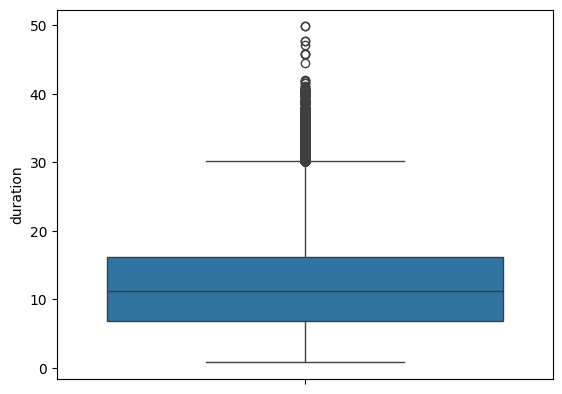

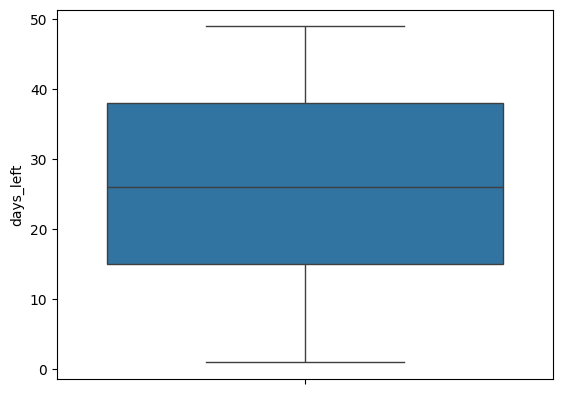

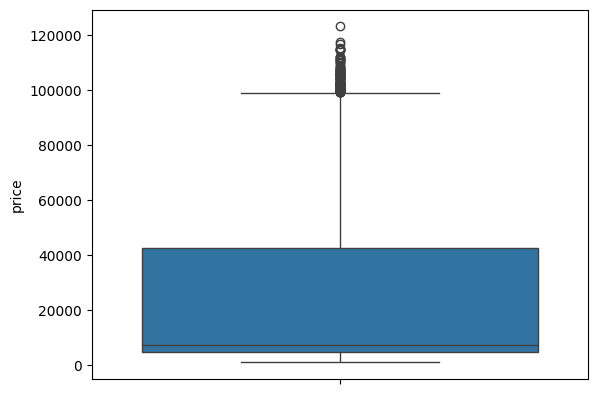

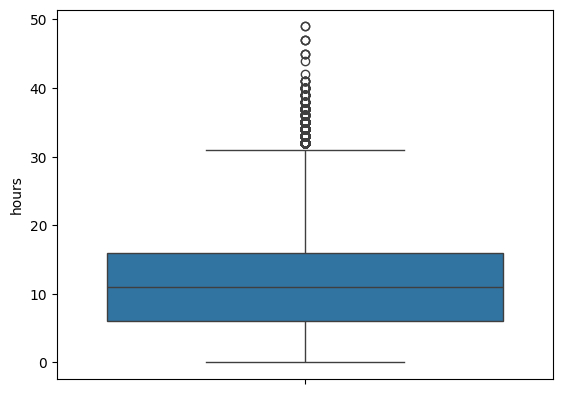

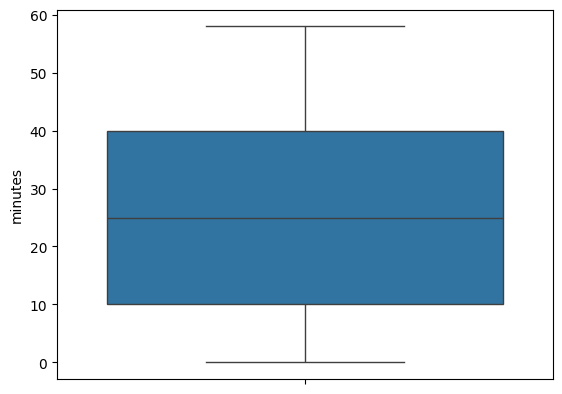

In [24]:
for col in df.columns:
  if(df[col].dtype =='int64' or df[col].dtype=='float64'):
    sns.boxplot(df[col])
    plt.show()

In [25]:
#data visualization airlines vs price

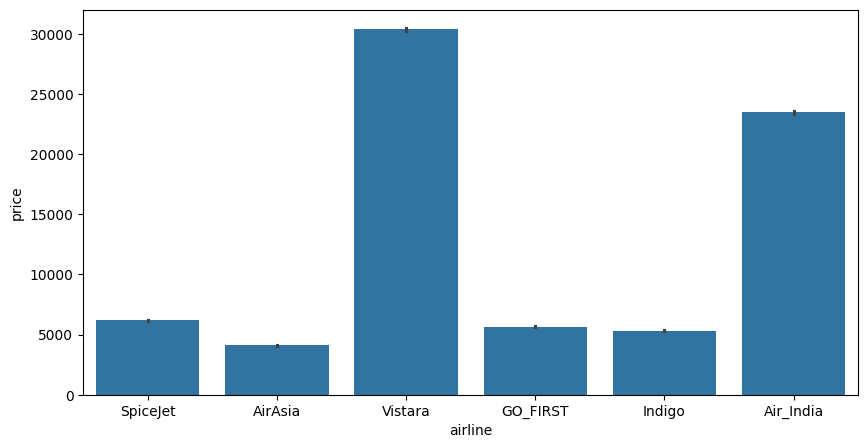

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(x='airline',y='price',data=df)
plt.show()

In [31]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [33]:
for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=le.fit_transform(df[col])


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   airline           300153 non-null  int64
 1   flight            300153 non-null  int64
 2   source_city       300153 non-null  int64
 3   departure_time    300153 non-null  int64
 4   stops             300153 non-null  int64
 5   arrival_time      300153 non-null  int64
 6   destination_city  300153 non-null  int64
 7   class             300153 non-null  int64
 8   duration          300153 non-null  int64
 9   days_left         300153 non-null  int64
 10  price             300153 non-null  int64
 11  hours             300153 non-null  int64
 12  minutes           300153 non-null  int64
dtypes: int64(13)
memory usage: 29.8 MB


In [37]:
df = df.drop(columns =["duration"])

KeyError: "['duration'] not found in axis"

In [39]:
#variation inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list=[]
for col in df.columns:
  if((df[col].dtype!='object') &(col!='price')):
    col_list.append(col)
X=df[col_list]
vif_data=pd.DataFrame()
vif_data["feature"]=X.columns
vif_data['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print(vif_data)

             feature        VIF
0            airline   6.701700
1             flight  12.752910
2        source_city   2.992546
3     departure_time   2.810801
4              stops   1.443561
5       arrival_time   3.812901
6   destination_city   2.944963
7              class   2.903451
8          days_left   3.910404
9              hours   4.552102
10           minutes   2.979102


In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list=[]
for col in df.columns:
  if((df[col].dtype!='object')&(col!='price')):
    col_list.append(col)
X=df[col_list]
vif_data=pd.DataFrame()
vif_data["Feature"]=X.columns
vif_data["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print(vif_data)

             Feature        VIF
0            airline   6.701700
1             flight  12.752910
2        source_city   2.992546
3     departure_time   2.810801
4              stops   1.443561
5       arrival_time   3.812901
6   destination_city   2.944963
7              class   2.903451
8          days_left   3.910404
9              hours   4.552102
10           minutes   2.979102


In [41]:
X=df.drop(columns=["price","flight"])
y=df["price"]

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [45]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
lr=LinearRegression()

In [49]:
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)


In [50]:
y_pred

array([ 1889.79243416,  9724.319293  ,  2114.31305289, ...,
        2358.87379419,   630.71783383, 12885.73388161])

In [51]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.8648498380147924
1174.594252681421
6188891088681515.0
2280636.9005483026
1510.177771174077


In [52]:
#model ---2

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

y_pred

array([ 3447., 11033.,  2491., ...,  2592.,  1577., 10919.])

In [53]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.9651895083356529
279.86317902417085
258073040898111.28
587421.3589520415
766.4341843576925


In [54]:
#model -3
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)

y_pred

array([ 2535.28, 11138.1 ,  2491.  , ...,  2701.49,  1139.12, 11171.34])

In [55]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.9803911380691713
254.7965783449715
384550174478922.9
330896.34107948374
575.2359003743453


/tmp/ipykernel_168/2134867668.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test , label ="ACtual")
/tmp/ipykernel_168/2134867668.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label ="predicted")


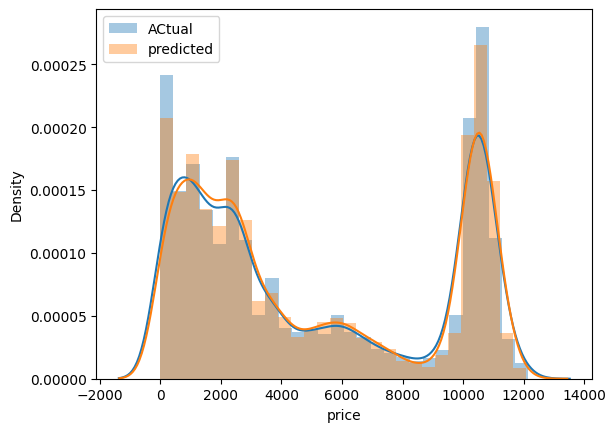

In [56]:
sns.distplot(y_test , label ="ACtual")
sns.distplot(y_pred, label ="predicted")

plt.legend()